# Métricas de Clasificación

## 1. Importación de librerías y configuración inicial

En esta sección se importan las librerías necesarias para trabajar con modelos de clasificación, preprocesamiento de datos y evaluación mediante distintas métricas.

Se utilizarán modelos como **Regresión Logística**, **Random Forest**, **Support Vector Machine (SVM)** y un **Dummy Classifier** como modelo de referencia.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
)

# Semilla para reproducibilidad
RANDOM_STATE = 42

# Configuración de visualización de pandas
pd.set_option("display.width", 130)

# Configuración de gráficos
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10
})

# Función auxiliar para mostrar números con 4 decimales
fmt = lambda v: f"{v:.4f}"

print("ready")

ready


# 0. Setup — and one trap in the data

Before computing a single metric, we first need to answer an important question:

**Which class is considered "positive"?**

Every classification metric below depends on this choice, and `scikit-learn` will not warn us if we choose the wrong positive class.

In the Breast Cancer dataset:

- `target = 0` → **malignant**
- `target = 1` → **benign**

By default, metrics such as `precision_score`, `recall_score`, and `f1_score` use `pos_label=1`. Therefore, without making any changes, these metrics would evaluate the **benign** class as the positive class.

However, for this analysis we are interested in correctly identifying **malignant tumors**.

Therefore, we will explicitly define:

**positive = malignant = 1**

In [3]:
# ============================================================
# 0. SETUP — IDENTIFICACIÓN DE LAS CLASES
# ============================================================

# Cargar el dataset de cáncer de mama
data = load_breast_cancer()

# Mostrar los nombres de las clases
print("target_names:", list(data.target_names))

# Mostrar la distribución de cada clase
for value, name in enumerate(data.target_names):
    n = (data.target == value).sum()

    print(
        f"  target = {value} -> {name:<10s} "
        f"{n:>4d} cases ({n / len(data.target):.1%})"
    )

target_names: [np.str_('malignant'), np.str_('benign')]
  target = 0 -> malignant   212 cases (37.3%)
  target = 1 -> benign      357 cases (62.7%)


## Definición de la clase positiva y división Train/Test

El dataset original codifica las clases como:

- `0 = malignant`
- `1 = benign`

Para este análisis se redefine la variable objetivo de manera que la clase de mayor interés sea la positiva:

- `0 = benign`
- `1 = malignant`

Posteriormente, los datos se dividen en conjuntos de **entrenamiento (70%)** y **prueba (30%)**.

Se utiliza el parámetro `stratify=y` para conservar aproximadamente la misma proporción de tumores malignos y benignos en ambos conjuntos.

In [4]:
# ============================================================
# DEFINICIÓN DE LA CLASE POSITIVA
# ============================================================

X = data.data

# 1 = malignant, la clase que nos interesa detectar
y = (data.target == 0).astype(int)

CLASSES = ["benign", "malignant"]

# Mostrar distribución de las clases
print(
    f"positives (malignant): {y.sum():>4d}   "
    f"prevalence {y.mean():.1%}"
)

print(
    f"negatives (benign):    {(1 - y).sum():>4d}"
)


# ============================================================
# DIVISIÓN TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(
    f"\ntrain {X_train.shape[0]} rows | "
    f"test {X_test.shape[0]} rows"
)

print(
    f"stratify keeps the prevalence: "
    f"train {y_train.mean():.3f} | "
    f"test {y_test.mean():.3f}"
)

positives (malignant):  212   prevalence 37.3%
negatives (benign):     357

train 398 rows | test 171 rows
stratify keeps the prevalence: train 0.372 | test 0.374


## Escalamiento de las características

Las variables del dataset tienen rangos muy diferentes, llegando a abarcar varios órdenes de magnitud.

Los modelos regularizados y aquellos basados en distancias, como **Logistic Regression** y **SVM**, no son invariantes a la escala. Por ello, se utiliza `StandardScaler` dentro de un `Pipeline`.

En cambio, **Random Forest** no requiere escalamiento porque los árboles de decisión no dependen de distancias entre observaciones.

También se comparará un SVM con y sin escalamiento para observar directamente el efecto del preprocesamiento.

In [5]:
# ============================================================
# ESCALAMIENTO DE LAS CARACTERÍSTICAS
# ============================================================

# Revisar los rangos de algunas variables
ranges = pd.DataFrame(
    {
        "min": X.min(axis=0),
        "max": X.max(axis=0)
    },
    index=data.feature_names
)

print("a few feature ranges -- four orders of magnitude apart:")

print(
    ranges.loc[
        [
            "mean fractal dimension",
            "mean smoothness",
            "mean radius",
            "mean perimeter",
            "worst area"
        ]
    ].to_string(
        float_format=lambda v: f"{v:10.4f}"
    )
)


# ============================================================
# DEFINICIÓN DE LOS MODELOS
# ============================================================

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE
        )
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),

    "SVM (RBF)": make_pipeline(
        StandardScaler(),
        SVC(
            probability=True,
            random_state=RANDOM_STATE
        )
    )
}


# ============================================================
# ENTRENAMIENTO DE LOS MODELOS
# ============================================================

for name, m in models.items():
    m.fit(X_train, y_train)


# ============================================================
# EFECTO DEL ESCALAMIENTO EN SVM
# ============================================================

# What scaling is actually worth on this data:
raw_svm = SVC(
    random_state=RANDOM_STATE
).fit(X_train, y_train)

print(
    f"\nSVM without scaling: accuracy "
    f"{accuracy_score(y_test, raw_svm.predict(X_test)):.4f}"
)

print(
    f"SVM with scaling:    accuracy "
    f"{accuracy_score(y_test, models['SVM (RBF)'].predict(X_test)):.4f}"
)

print("Same algorithm. The gap is preprocessing, not the model.")

a few feature ranges -- four orders of magnitude apart:
                              min        max
mean fractal dimension     0.0500     0.0974
mean smoothness            0.0526     0.1634
mean radius                6.9810    28.1100
mean perimeter            43.7900   188.5000
worst area               185.2000  4254.0000

SVM without scaling: accuracy 0.9006
SVM with scaling:    accuracy 0.9591
Same algorithm. The gap is preprocessing, not the model.


# 1. Every prediction falls into one of four boxes

## Matriz de Confusión

Una matriz de confusión permite comparar los valores reales con las predicciones realizadas por un modelo de clasificación.

Para un problema binario, cada predicción pertenece a una de cuatro categorías:

- **TP (True Positive):** tumor maligno correctamente detectado.
- **FN (False Negative):** tumor maligno clasificado incorrectamente como benigno.
- **FP (False Positive):** tumor benigno clasificado incorrectamente como maligno.
- **TN (True Negative):** tumor benigno correctamente clasificado.

En este problema, los **False Negatives (FN)** son especialmente importantes, ya que representan tumores malignos que el modelo no logró detectar.

En `scikit-learn`, las filas de la matriz representan los valores reales (`truth`) y las columnas representan las predicciones (`prediction`).

In [6]:
# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

# Seleccionamos el modelo de Regresión Logística
model = models["Logistic Regression"]

# Generamos predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)


# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred)  # rows = truth, columns = prediction

# Extraemos los cuatro componentes de la matriz
tn, fp, fn, tp = cm.ravel()


# ============================================================
# MOSTRAR LA MATRIZ
# ============================================================

print("scikit-learn puts TRUTH on the rows and PREDICTION on the columns.")

print(
    "Slide 28 warns about this: several textbooks print the transpose.\n"
)

print(
    pd.DataFrame(
        cm,
        index=[f"actual {c}" for c in CLASSES],
        columns=[f"predicted {c}" for c in CLASSES]
    )
)


# ============================================================
# INTERPRETACIÓN DE LOS RESULTADOS
# ============================================================

print(f"\nTP = {tp:>3d}   malignant, correctly caught")

print(
    f"FN = {fn:>3d}   malignant, missed"
    "          <-- the dangerous error"
)

print(f"FP = {fp:>3d}   benign, false alarm")

print(f"TN = {tn:>3d}   benign, correctly cleared")

scikit-learn puts TRUTH on the rows and PREDICTION on the columns.
Slide 28 warns about this: several textbooks print the transpose.

                  predicted benign  predicted malignant
actual benign                  106                    1
actual malignant                 4                   60

TP =  60   malignant, correctly caught
FN =   4   malignant, missed          <-- the dangerous error
FP =   1   benign, false alarm
TN = 106   benign, correctly cleared


## Visualización de la Matriz de Confusión

A continuación se representa gráficamente la matriz de confusión obtenida para el modelo de **Logistic Regression** sobre el conjunto de prueba.

Las filas representan las clases reales (`Actual`) y las columnas representan las clases predichas (`Predicted`).

Esta visualización permite identificar rápidamente:

- **True Negatives (TN):** benignos correctamente clasificados.
- **False Positives (FP):** benignos clasificados como malignos.
- **False Negatives (FN):** malignos clasificados como benignos.
- **True Positives (TP):** malignos correctamente detectados.

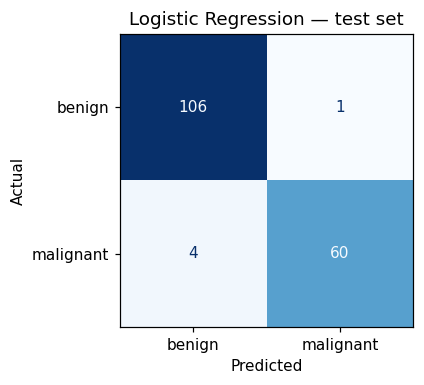

In [8]:
# ============================================================
# VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(4.3, 3.6))

ConfusionMatrixDisplay(
    cm,
    display_labels=CLASSES
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

ax.set_title("Logistic Regression — test set")

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# 2. Accuracy, and where it breaks

## Cálculo de Accuracy

La métrica **Accuracy** representa la proporción total de predicciones correctas realizadas por el modelo.

A partir de la matriz de confusión se calcula como:

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

Primero se calculará manualmente utilizando los elementos de la matriz de confusión y posteriormente se verificará el resultado utilizando `accuracy_score` de `scikit-learn`.

In [9]:
# ============================================================
# 2. ACCURACY
# ============================================================

# Accuracy calculada directamente desde la matriz de confusión
print(
    f"accuracy from the matrix : "
    f"{(tp + tn) / cm.sum():.4f}"
)

# Accuracy calculada con scikit-learn
print(
    f"accuracy from sklearn    : "
    f"{accuracy_score(y_test, y_pred):.4f}"
)

accuracy from the matrix : 0.9708
accuracy from sklearn    : 0.9708


## The baseline accuracy hides

Aunque un valor alto de **Accuracy** puede parecer indicar que un modelo funciona correctamente, esta métrica puede ser engañosa cuando existe un fuerte desbalance entre las clases.

El dataset de cáncer de mama contiene aproximadamente un **37% de casos malignos**, por lo que todavía está relativamente balanceado y no permite observar claramente este problema.

Para demostrarlo se utilizará un **dataset sintético de detección de fraude**, donde la clase positiva representa aproximadamente el **1% de las observaciones**.

El dataset tendrá:

- **20,000 observaciones**
- 20 características
- Una clase mayoritaria cercana al 99%
- Una clase minoritaria correspondiente a casos de fraude

Esto permitirá analizar por qué un modelo puede alcanzar una Accuracy muy alta incluso si prácticamente no detecta casos positivos.

In [11]:
# ============================================================
# DATASET SINTÉTICO DESBALANCEADO
# ============================================================

from sklearn.datasets import make_classification

# Crear un dataset sintético similar a un problema
# de detección de fraude
X_imb, y_imb = make_classification(
    n_samples=20_000,
    n_features=20,
    n_informative=6,
    n_redundant=2,
    weights=[0.99, 0.01],
    flip_y=0.01,
    class_sep=0.9,
    random_state=RANDOM_STATE
)


# ============================================================
# DIVISIÓN TRAIN / TEST
# ============================================================

X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb,
    y_imb,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_imb
)


# ============================================================
# VERIFICAR EL DESBALANCE
# ============================================================

print(
    f"synthetic fraud data: {len(y_imb):,} rows, "
    f"prevalence {y_imb.mean():.2%}"
)

print(
    f"  train {len(y_imb_tr):,} rows "
    f"({y_imb_tr.sum()} frauds)"
)

print(
    f"  test  {len(y_imb_te):,} rows "
    f"({y_imb_te.sum()} frauds)"
)

synthetic fraud data: 20,000 rows, prevalence 1.45%
  train 14,000 rows (203 frauds)
  test  6,000 rows (87 frauds)
